In [51]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Define the title and authors
title = "Fabre Museum Project: Observational Data Analysis"
authors = "Amélie Goubé"

# Get the current date and format it
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")

# Display the header using Markdown
display(Markdown(f"# {title}"))
display(Markdown(f"**Date:** {current_date}"))
display(Markdown(f"**Author:** {authors}"))

# Fabre Museum Project: Observational Data Analysis

**Date:** 12 May 2026, 02:04:14

**Author:** Amélie Goubé

# 1. Introduction

## 1.1. Project Context
This project focuses on analyzing children's **movements** and **spatial interactions** at the **Fabre Museum**.

## 1.2. Objectives

1.  **Data Cleaning & Standardization**: 
    * Harmonizing column names (snake_case) for cross-platform compatibility (Python/R).
    * Handling missing values (`NA`) and stripping whitespace.
    * Ensuring correct data types for numerical analysis.

2.  **Structural Grouping (Dimensional Analysis)**:
    Categorizing the 15+ raw variables into four meaningful behavioral dimensions:
    * **Spatial Exploration**: Measuring mobility and autonomy.
    * **Engagement with Artwork**: Focusing on posture and visual orientation.
    * **Motor Engagement**: Analyzing physical interaction with the environment.
    * **Social Interactions**: Observing peer-to-peer and child-adult dynamics.

3.  **Visual Exploration & Pipeline Export**:
    * Generating comparative statistics by **gender** to identify initial behavioral trends.
    * Producing a **correlation matrix** to observe the relationships between variables.
    * Exporting a "Tidy" dataset (`data_clean.csv`) to ensure a seamless transition to **RStudio**.


In [52]:
# load the data 
#the data is in the file data as a .txt file 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# import data
df= pd.read_csv('data/data_observation.csv', sep=";")
# display first 5 rows of the data
print(df.head())

  children_id sex observer  number_of_group_movements  \
0      obs1_f   f     obs1                        4.0   
1      obs1_g   g     obs1                        4.0   
2      obs2_f   f     obs2                        5.0   
3      obs2_g   g     obs2                        5.0   
4      obs3_f   f     obs3                        4.0   

   number_of_zones_explored  distance_travelled  movement_autonomy  \
0                       8.0                 300                  0   
1                       8.0                 300                  1   
2                       0.0                 300                  1   
3                       0.0                 300                  1   
4                       4.0                 300                  1   

   number_of_spontaneous_outings  orientation_towards_artwork  \
0                              0                            2   
1                              1                            1   
2                              4         

In [54]:
# Verify the missing values in the data
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
children_id                           0
sex                                   0
observer                              0
number_of_group_movements             2
number_of_zones_explored              2
distance_travelled                    0
movement_autonomy                     0
number_of_spontaneous_outings         0
orientation_towards_artwork           0
physical_approach                     2
offset_approach                       2
postural_adjustment                   0
overall_motor_engagement              0
interaction_with_environment          0
observation_time                      8
number_of_stops_during_observation    0
interaction_with_peers                0
interaction_with_adults               2
dtype: int64


In [55]:
# standardize column names: strip whitespace, convert to lowercase, replace spaces with underscores, and handle special characters
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("é", "e")
    .str.replace("è", "e")
    .str.replace("œ", "oe")
)


In [56]:
#replace "NA" with pd.NA to standardize missing values
df = df.replace("NA", pd.NA)
df = df.replace("", pd.NA)

#drop rows where all values are missing
df = df.dropna(how='all')
print (df.head())

  children_id sex observer  number_of_group_movements  \
0      obs1_f   f     obs1                        4.0   
1      obs1_g   g     obs1                        4.0   
2      obs2_f   f     obs2                        5.0   
3      obs2_g   g     obs2                        5.0   
4      obs3_f   f     obs3                        4.0   

   number_of_zones_explored  distance_travelled  movement_autonomy  \
0                       8.0                 300                  0   
1                       8.0                 300                  1   
2                       0.0                 300                  1   
3                       0.0                 300                  1   
4                       4.0                 300                  1   

   number_of_spontaneous_outings  orientation_towards_artwork  \
0                              0                            2   
1                              1                            1   
2                              4         

In [57]:
#
df.groupby("sex").mean(numeric_only=True)

,number_of_group_movements,number_of_zones_explored,distance_travelled,movement_autonomy,number_of_spontaneous_outings,orientation_towards_artwork,physical_approach,offset_approach,postural_adjustment,overall_motor_engagement,interaction_with_environment,observation_time,number_of_stops_during_observation,interaction_with_peers,interaction_with_adults
sex,,,,,,,,,,,,,,,
f,4.0,5.25,300.0,0.4,0.8,1.6,0.00,0.00,1.2,1.0,1.4,4.0,0.6,0.8,1.0
g,4.0,5.25,300.0,0.6,0.6,1.4,0.25,0.25,2.4,1.2,1.0,4.0,0.6,0.6,0.5


## 2. Dimensional Analysis
We categorize the observed behaviors into four main dimensions to better understand the children's museum experience.

In [58]:

#Definition of the variables for each dimension`
variables = {
    "Spatial Exploration": [
        'number_of_zones_explored', 'distance_travelled', 'movement_autonomy'
    ],
    "Engagement with Artwork": [
        'orientation_towards_artwork', 'postural_adjustment', 'physical_approach'
    ],
    "Motor Engagement": [
        'overall_motor_engagement', 'interaction_with_environment'
    ],
    "Social Interactions": [
        'interaction_with_peers', 'interaction_with_adults'
    ]
}
# Create a flat list of all variables named in the dictionary
all_vars = [var for sublist in variables.values() for var in sublist]

# Filter the dataframe to keep only 'sex' and the variables of interest
# We use .copy() to create a dedicated dataframe for analysis
df_analysis = df[['sex'] + all_vars].copy()

# Display the mean scores for each dimension by gender
print("Mean Scores by Dimension and Gender")
for dimension, cols in variables.items():
    print(f"\nDimension: {dimension}")
    # Display the mean for this specific group of variables
    display(df_analysis.groupby("sex")[cols].mean().round(2))



Mean Scores by Dimension and Gender

Dimension: Spatial Exploration


,number_of_zones_explored,distance_travelled,movement_autonomy
sex,,,
f,5.25,300.0,0.4
g,5.25,300.0,0.6



Dimension: Engagement with Artwork


,orientation_towards_artwork,postural_adjustment,physical_approach
sex,,,
f,1.6,1.2,0.00
g,1.4,2.4,0.25



Dimension: Motor Engagement


,overall_motor_engagement,interaction_with_environment
sex,,
f,1.0,1.4
g,1.2,1.0



Dimension: Social Interactions


,interaction_with_peers,interaction_with_adults
sex,,
f,0.8,1.0
g,0.6,0.5


## 3. Descriptive Statistics
After cleaning the data, we generate descriptive statistics to summarize the main characteristics of our dataset.

### 3.1. General Overview
We use the `.describe()` method to calculate key metrics such as:
* **Count**: Number of valid observations.
* **Mean & Standard Deviation**: To understand the central tendency and dispersion.
* **Min/Max & Quartiles**: To observe the range of behaviors.

### 3.2. Gender-Based Comparison
To address the core research question, we group the data by **Sex** and calculate the mean for each behavioral variable. This allows us to identify initial trends between boys ('g') and girls ('f').

*Note: All tables are exported as high-resolution images in the `results/` folder for the final report.*

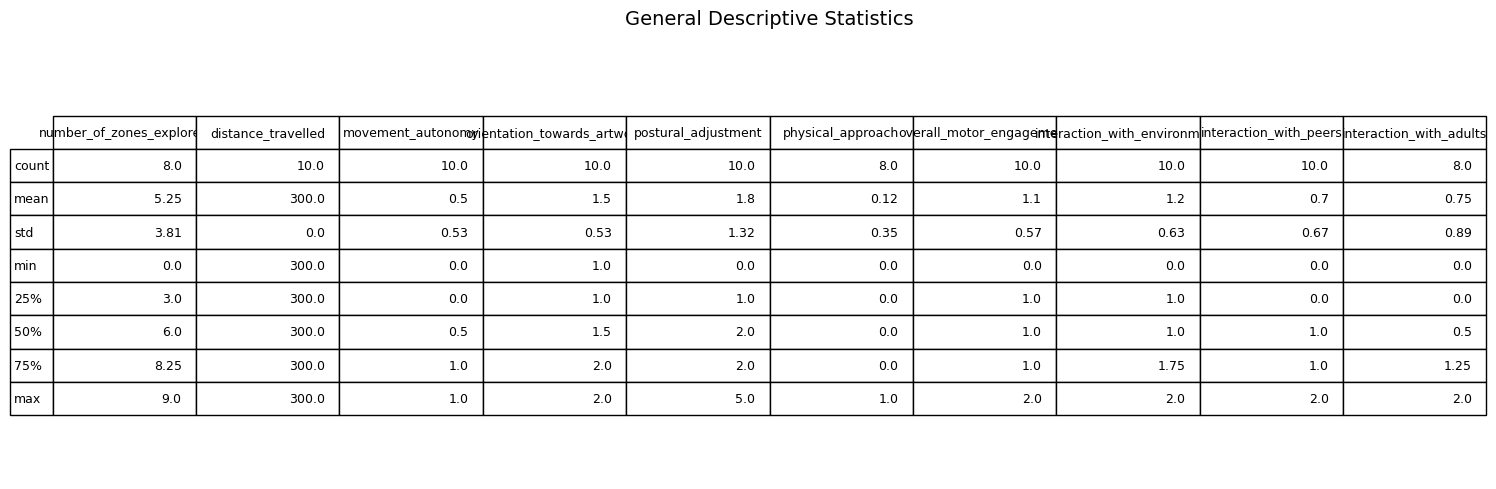

In [59]:
# Utilisation de df_analysis (ton DataFrame filtré par dimensions)
desc = df_analysis.describe().round(2)

# Ensure non-numerical identifiers are excluded
desc = desc.drop(columns=['children_id', 'observer'], errors='ignore')

# Create the figure for the general table
fig, ax = plt.subplots(figsize=(15, 5)) # Taille augmentée pour la lisibilité
ax.axis('off')

table = ax.table(
    cellText=desc.values,
    colLabels=desc.columns,
    rowLabels=desc.index,
    loc='center'
)

# Table Styling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

plt.title("General Descriptive Statistics", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig("results/descriptive_statistics.png", dpi=300, bbox_inches='tight')
plt.show()


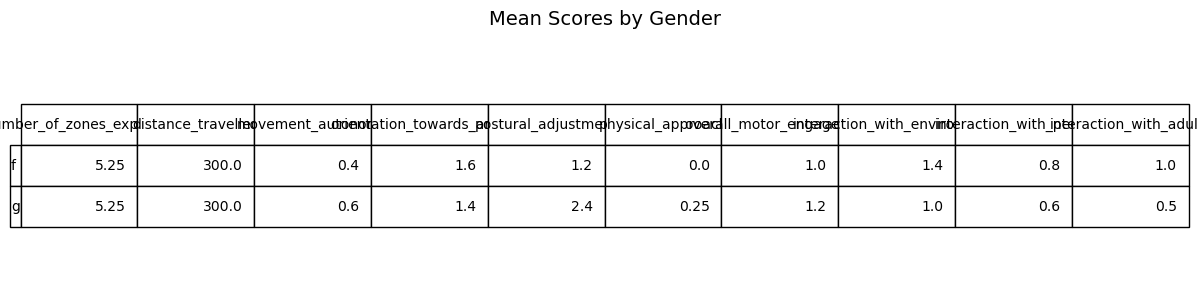

In [60]:

# Group by sex and calculate the mean for all numeric columns
desc_sex = df_analysis.groupby('sex').mean(numeric_only=True).round(2)

# Create the figure for the gender comparison table
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table = ax.table(
    cellText=desc_sex.values,
    colLabels=desc_sex.columns,
    rowLabels=desc_sex.index,
    loc='center'
)

# Table Styling
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5) # Scale vertical plus grand pour bien lire les deux lignes

plt.title("Mean Scores by Gender", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig("results/descriptive_statistics_sex.png", dpi=300, bbox_inches='tight')
plt.show()


## 4. Correlation Analysis
To conclude our exploratory analysis, we examine the relationships between the different behavioral variables. 

We generate a **Correlation Matrix**, visualized as a heatmap, which helps us:
* **Identify patterns**: See which behaviors tend to occur together (e.g., does a high number of explored zones correlate with more physical approaches to artwork?).
* **Check for redundancy**: Ensure that the variables we grouped into dimensions are actually related.
* **Validate the dimensions**: High correlation coefficients (closer to +1 or -1) indicate strong linear relationships, while values near 0 suggest independent behaviors.

The resulting heatmap is automatically saved as `correlation_heatmap.png` in the `results/` folder.

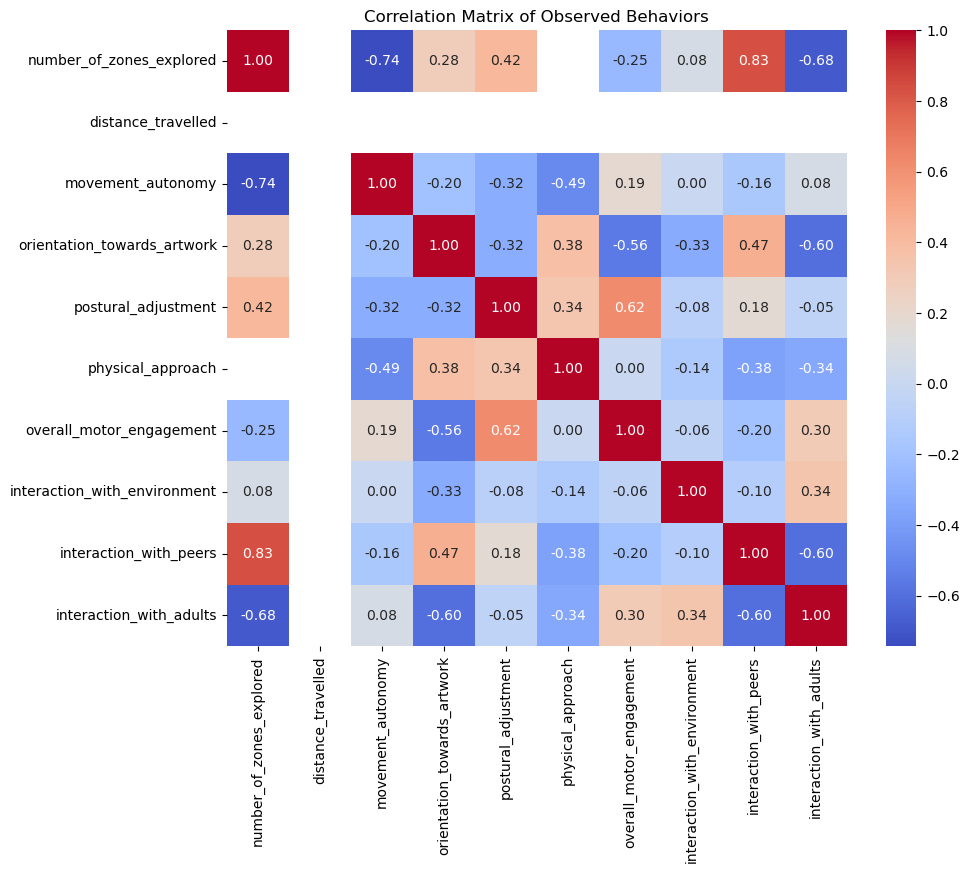

In [61]:
# Initialize the figure size
plt.figure(figsize=(10, 8))

# Calculate the correlation matrix (only for numerical values)
correlation_matrix = df_analysis.corr(numeric_only=True)

# Generate the heatmap using Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title and formatting
plt.title("Correlation Matrix of Observed Behaviors")

# Save the figure to the results folder before displaying
plt.savefig("results/correlation_heatmap.png")
plt.show()

## 5. Data Export for R Analysis
The final stage of the Python workflow is to bridge the gap between data pre-processing and statistical modeling. 

We export the cleaned and structured dataset to a new CSV file named `data_clean.csv`. This ensures that:
* **Consistency**: All column names and formatting remain standardized.
* **Integrity**: The R script will work on a "tidy" version of the data without missing or corrupted rows.
* **Separation of Concerns**: We keep the raw data (`data_observation.csv`) untouched and perform all analysis on the processed version.

This file will serve as the primary input for the **RStudio** portion of the project.

In [62]:
# Saving the cleaned dataframe to the data folder
# We use ';' as a separator to stay consistent with the original file format
df_analysis.to_csv(
    "data/data_clean.csv", 
    sep=";", 
    index=False, 
    encoding="utf-8"
)

## 6. Preliminary Observations and Perspectives
This exploratory phase in Python allowed us to clean the dataset and identify initial behavioral trends. Based on the descriptive statistics, we can draw the following preliminary observations:

* **Spatial Autonomy**: While spatial exploration (distance and zones) appears strictly identical between genders, boys might exhibit slightly higher movement autonomy than girls.
* **Engagement Styles**: A distinction in how children interact with artworks seems to emerge; girls would favor visual orientation, whereas boys might demonstrate more dynamic physical involvement, characterized by more frequent postural adjustments.
* **Social Dynamics**: Girls would appear to have a more socially-integrated experience, potentially interacting twice as much with adults and more frequently with their peers compared to boys.
* **Methodological Transition**: These observations remain hypothetical at this stage. It would be necessary to perform inferential statistical tests (such as T-tests or ANOVAs) in **RStudio** to confirm whether these differences are statistically significant or merely due to the small sample size.

**The data is now standardized and ready for the next phase of the pipeline in R.**